# TomatoFarmEnv-v0 — DQN Hyperparameter Experiments
> **Algorithm:** Deep Q-Network (Value-Based) | **Library:** Stable-Baselines3
> Each experiment saves its model. The best model is exported to `best_dqn_info.json` for use in `main.py`.

## Hyperparameters Under Investigation

| Parameter | What it controls |
|-----------|-----------------|
| `learning_rate` | Q-network gradient step size |
| `buffer_size` | Replay memory capacity |
| `gamma` | Discount factor for future rewards |
| `batch_size` | Samples drawn per gradient update |
| `exploration_fraction` | Fraction of training for ε-greedy annealing |
| `exploration_final_eps` | Final ε value after annealing |
| `target_update_interval` | Steps between target network syncs |
| `train_freq` | Steps between Q-network gradient updates |


In [1]:
# Install all dependencies
!pip install gymnasium stable-baselines3 torch matplotlib pandas numpy -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 17.4 MB/s eta 0:00:00


In [2]:
# Upload tomato_farm_env.py from your local machine
from google.colab import files
uploaded = files.upload()   # pick tomato_farm_env.py


Saving tomato_farm_env.py to tomato_farm_env.py


In [3]:
import os, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

MODELS_DIR = "saved_models"
os.makedirs(MODELS_DIR, exist_ok=True)

results_log = []   # one dict per experiment

def record(exp_id, label, algo, params, rewards, model_path, wall_time):
    arr = np.array(rewards)
    results_log.append({
        "exp_id":       exp_id,
        "label":        label,
        "algo":         algo,
        "mean_reward":  round(float(arr.mean()), 2),
        "std_reward":   round(float(arr.std()),  2),
        "max_reward":   round(float(arr.max()),  2),
        "min_reward":   round(float(arr.min()),  2),
        "wall_time_s":  round(wall_time, 1),
        "model_path":   model_path,
        **params,
    })

def show_results_table():
    df = pd.DataFrame(results_log)
    pd.set_option("display.max_columns", 30)
    pd.set_option("display.width", 240)
    print(df.to_string(index=False))
    return df

def plot_comparison(rewards_dict, title):
    n = len(rewards_dict)
    cols = 5; rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(22, rows * 4), facecolor="#0f1a0f")
    fig.suptitle(title, color="#f0d435", fontsize=14, fontweight="bold")
    for ax, (label, rewards) in zip(axes.flatten(), rewards_dict.items()):
        w = max(1, len(rewards) // 20)
        smoothed = np.convolve(rewards, np.ones(w) / w, mode="valid")
        ax.plot(rewards, alpha=0.25, color="#4a8fe8", linewidth=0.8, label="raw")
        ax.plot(smoothed, color="#3ddc5f", linewidth=2.0, label="smoothed")
        ax.set_facecolor("#162116")
        ax.set_title(label, color="#f0d435", fontsize=8)
        ax.tick_params(colors="#7a8a7a", labelsize=7)
        for spine in ax.spines.values():
            spine.set_color("#2e5e2e")
        ax.axhline(0, color="#e85050", linewidth=0.7, linestyle="--")
        ax.legend(fontsize=6, facecolor="#0f1a0f", labelcolor="#e8eae8")
    for ax in axes.flatten()[n:]:
        ax.set_visible(False)
    plt.tight_layout()
    fname = title.replace(" ", "_") + ".png"
    plt.savefig(fname, dpi=150, bbox_inches="tight", facecolor="#0f1a0f")
    plt.show()
    print(f"Saved: {fname}")

def save_best_model_path(algo, results):
    best = max(results, key=lambda x: x["mean_reward"])
    info = {
        "algo":        algo,
        "label":       best["label"],
        "mean_reward": best["mean_reward"],
        "model_path":  best["model_path"],
        "params":      {k: v for k, v in best.items()
                        if k not in ("exp_id","label","algo","mean_reward",
                                     "std_reward","max_reward","min_reward",
                                     "wall_time_s","model_path")},
    }
    path = f"best_{algo.lower()}_info.json"
    with open(path, "w") as f:
        json.dump(info, f, indent=2)
    print(f"\nBest {algo} experiment: [{best['label']}]  mean={best['mean_reward']:.2f}")
    print(f"Best model info saved → {path}")
    return info

def eval_model_sb3(model, env_cls, n_eval=20, seed=99):
    from tomato_farm_env import TomatoFarmEnv
    env = env_cls()
    rewards = []
    for i in range(n_eval):
        obs, _ = env.reset(seed=seed + i)
        done = False; total = 0.0
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, r, terminated, truncated, _ = env.step(int(action))
            total += r
            done = terminated or truncated
        rewards.append(total)
    env.close()
    return rewards


In [4]:
dqn_rewards_dict = {}

## Experiments E01 – E10

In [5]:
# ── Experiment 1/10: E01-baseline ─────────────────────────────────────
from stable_baselines3 import DQN
from tomato_farm_env import TomatoFarmEnv
import time, numpy as np

params = dict(
    learning_rate          = 0.0003,
    buffer_size            = 10000,
    gamma                  = 0.99,
    batch_size             = 64,
    exploration_fraction   = 0.2,
    exploration_final_eps  = 0.05,
    target_update_interval = 500,
    train_freq             = 4,
    timesteps              = 100000,
)

env_dqn1 = TomatoFarmEnv()
t0 = time.time()

model_dqn1 = DQN(
    "MlpPolicy", env_dqn1,
    learning_rate          = params["learning_rate"],
    buffer_size            = params["buffer_size"],
    gamma                  = params["gamma"],
    batch_size             = params["batch_size"],
    exploration_fraction   = params["exploration_fraction"],
    exploration_final_eps  = params["exploration_final_eps"],
    target_update_interval = params["target_update_interval"],
    train_freq             = params["train_freq"],
    verbose=0, seed=42,
)
model_dqn1.learn(total_timesteps=100000)
wall_dqn1 = time.time() - t0

# Save model
save_path_dqn1 = f"{MODELS_DIR}/DQN_E01-baseline"
model_dqn1.save(save_path_dqn1)
print(f"  Model saved → {save_path_dqn1}.zip")

# Evaluate
rewards_dqn1 = eval_model_sb3(model_dqn1, TomatoFarmEnv)
record(1, "E01-baseline", "DQN", params, rewards_dqn1, save_path_dqn1 + ".zip", wall_dqn1)

print(f"[1/10] E01-baseline | "
      f"mean={np.mean(rewards_dqn1):.1f} ± {np.std(rewards_dqn1):.1f} | "
      f"max={np.max(rewards_dqn1):.1f} | {wall_dqn1:.0f}s")
env_dqn1.close()

dqn_rewards_dict["E01-baseline"] = rewards_dqn1


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  Model saved → saved_models/DQN_E01-baseline.zip


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


[1/10] E01-baseline | mean=104.8 ± 65.4 | max=198.2 | 137s


In [6]:
# ── Experiment 2/10: E02-low_lr ─────────────────────────────────────
from stable_baselines3 import DQN
from tomato_farm_env import TomatoFarmEnv
import time, numpy as np

params = dict(
    learning_rate          = 0.0001,
    buffer_size            = 10000,
    gamma                  = 0.99,
    batch_size             = 64,
    exploration_fraction   = 0.2,
    exploration_final_eps  = 0.05,
    target_update_interval = 500,
    train_freq             = 4,
    timesteps              = 100000,
)

env_dqn2 = TomatoFarmEnv()
t0 = time.time()

model_dqn2 = DQN(
    "MlpPolicy", env_dqn2,
    learning_rate          = params["learning_rate"],
    buffer_size            = params["buffer_size"],
    gamma                  = params["gamma"],
    batch_size             = params["batch_size"],
    exploration_fraction   = params["exploration_fraction"],
    exploration_final_eps  = params["exploration_final_eps"],
    target_update_interval = params["target_update_interval"],
    train_freq             = params["train_freq"],
    verbose=0, seed=42,
)
model_dqn2.learn(total_timesteps=100000)
wall_dqn2 = time.time() - t0

# Save model
save_path_dqn2 = f"{MODELS_DIR}/DQN_E02-low_lr"
model_dqn2.save(save_path_dqn2)
print(f"  Model saved → {save_path_dqn2}.zip")

# Evaluate
rewards_dqn2 = eval_model_sb3(model_dqn2, TomatoFarmEnv)
record(2, "E02-low_lr", "DQN", params, rewards_dqn2, save_path_dqn2 + ".zip", wall_dqn2)

print(f"[2/10] E02-low_lr | "
      f"mean={np.mean(rewards_dqn2):.1f} ± {np.std(rewards_dqn2):.1f} | "
      f"max={np.max(rewards_dqn2):.1f} | {wall_dqn2:.0f}s")
env_dqn2.close()

dqn_rewards_dict["E02-low_lr"] = rewards_dqn2


  Model saved → saved_models/DQN_E02-low_lr.zip
[2/10] E02-low_lr | mean=90.2 ± 84.1 | max=273.8 | 132s


In [7]:
# ── Experiment 3/10: E03-high_lr ─────────────────────────────────────
from stable_baselines3 import DQN
from tomato_farm_env import TomatoFarmEnv
import time, numpy as np

params = dict(
    learning_rate          = 0.001,
    buffer_size            = 10000,
    gamma                  = 0.99,
    batch_size             = 64,
    exploration_fraction   = 0.2,
    exploration_final_eps  = 0.05,
    target_update_interval = 500,
    train_freq             = 4,
    timesteps              = 100000,
)

env_dqn3 = TomatoFarmEnv()
t0 = time.time()

model_dqn3 = DQN(
    "MlpPolicy", env_dqn3,
    learning_rate          = params["learning_rate"],
    buffer_size            = params["buffer_size"],
    gamma                  = params["gamma"],
    batch_size             = params["batch_size"],
    exploration_fraction   = params["exploration_fraction"],
    exploration_final_eps  = params["exploration_final_eps"],
    target_update_interval = params["target_update_interval"],
    train_freq             = params["train_freq"],
    verbose=0, seed=42,
)
model_dqn3.learn(total_timesteps=100000)
wall_dqn3 = time.time() - t0

# Save model
save_path_dqn3 = f"{MODELS_DIR}/DQN_E03-high_lr"
model_dqn3.save(save_path_dqn3)
print(f"  Model saved → {save_path_dqn3}.zip")

# Evaluate
rewards_dqn3 = eval_model_sb3(model_dqn3, TomatoFarmEnv)
record(3, "E03-high_lr", "DQN", params, rewards_dqn3, save_path_dqn3 + ".zip", wall_dqn3)

print(f"[3/10] E03-high_lr | "
      f"mean={np.mean(rewards_dqn3):.1f} ± {np.std(rewards_dqn3):.1f} | "
      f"max={np.max(rewards_dqn3):.1f} | {wall_dqn3:.0f}s")
env_dqn3.close()

dqn_rewards_dict["E03-high_lr"] = rewards_dqn3


  Model saved → saved_models/DQN_E03-high_lr.zip
[3/10] E03-high_lr | mean=13299.6 ± 17879.0 | max=53013.6 | 131s


In [8]:
# ── Experiment 4/10: E04-small_buf ─────────────────────────────────────
from stable_baselines3 import DQN
from tomato_farm_env import TomatoFarmEnv
import time, numpy as np

params = dict(
    learning_rate          = 0.0003,
    buffer_size            = 5000,
    gamma                  = 0.99,
    batch_size             = 64,
    exploration_fraction   = 0.2,
    exploration_final_eps  = 0.05,
    target_update_interval = 500,
    train_freq             = 4,
    timesteps              = 100000,
)

env_dqn4 = TomatoFarmEnv()
t0 = time.time()

model_dqn4 = DQN(
    "MlpPolicy", env_dqn4,
    learning_rate          = params["learning_rate"],
    buffer_size            = params["buffer_size"],
    gamma                  = params["gamma"],
    batch_size             = params["batch_size"],
    exploration_fraction   = params["exploration_fraction"],
    exploration_final_eps  = params["exploration_final_eps"],
    target_update_interval = params["target_update_interval"],
    train_freq             = params["train_freq"],
    verbose=0, seed=42,
)
model_dqn4.learn(total_timesteps=100000)
wall_dqn4 = time.time() - t0

# Save model
save_path_dqn4 = f"{MODELS_DIR}/DQN_E04-small_buf"
model_dqn4.save(save_path_dqn4)
print(f"  Model saved → {save_path_dqn4}.zip")

# Evaluate
rewards_dqn4 = eval_model_sb3(model_dqn4, TomatoFarmEnv)
record(4, "E04-small_buf", "DQN", params, rewards_dqn4, save_path_dqn4 + ".zip", wall_dqn4)

print(f"[4/10] E04-small_buf | "
      f"mean={np.mean(rewards_dqn4):.1f} ± {np.std(rewards_dqn4):.1f} | "
      f"max={np.max(rewards_dqn4):.1f} | {wall_dqn4:.0f}s")
env_dqn4.close()

dqn_rewards_dict["E04-small_buf"] = rewards_dqn4


  Model saved → saved_models/DQN_E04-small_buf.zip
[4/10] E04-small_buf | mean=96.7 ± 63.1 | max=196.7 | 130s


In [9]:
# ── Experiment 5/10: E05-large_buf ─────────────────────────────────────
from stable_baselines3 import DQN
from tomato_farm_env import TomatoFarmEnv
import time, numpy as np

params = dict(
    learning_rate          = 0.0003,
    buffer_size            = 50000,
    gamma                  = 0.99,
    batch_size             = 64,
    exploration_fraction   = 0.2,
    exploration_final_eps  = 0.05,
    target_update_interval = 500,
    train_freq             = 4,
    timesteps              = 100000,
)

env_dqn5 = TomatoFarmEnv()
t0 = time.time()

model_dqn5 = DQN(
    "MlpPolicy", env_dqn5,
    learning_rate          = params["learning_rate"],
    buffer_size            = params["buffer_size"],
    gamma                  = params["gamma"],
    batch_size             = params["batch_size"],
    exploration_fraction   = params["exploration_fraction"],
    exploration_final_eps  = params["exploration_final_eps"],
    target_update_interval = params["target_update_interval"],
    train_freq             = params["train_freq"],
    verbose=0, seed=42,
)
model_dqn5.learn(total_timesteps=100000)
wall_dqn5 = time.time() - t0

# Save model
save_path_dqn5 = f"{MODELS_DIR}/DQN_E05-large_buf"
model_dqn5.save(save_path_dqn5)
print(f"  Model saved → {save_path_dqn5}.zip")

# Evaluate
rewards_dqn5 = eval_model_sb3(model_dqn5, TomatoFarmEnv)
record(5, "E05-large_buf", "DQN", params, rewards_dqn5, save_path_dqn5 + ".zip", wall_dqn5)

print(f"[5/10] E05-large_buf | "
      f"mean={np.mean(rewards_dqn5):.1f} ± {np.std(rewards_dqn5):.1f} | "
      f"max={np.max(rewards_dqn5):.1f} | {wall_dqn5:.0f}s")
env_dqn5.close()

dqn_rewards_dict["E05-large_buf"] = rewards_dqn5


  Model saved → saved_models/DQN_E05-large_buf.zip
[5/10] E05-large_buf | mean=90.8 ± 65.8 | max=197.7 | 134s


In [10]:
# ── Experiment 6/10: E06-low_gamma ─────────────────────────────────────
from stable_baselines3 import DQN
from tomato_farm_env import TomatoFarmEnv
import time, numpy as np

params = dict(
    learning_rate          = 0.0003,
    buffer_size            = 10000,
    gamma                  = 0.9,
    batch_size             = 64,
    exploration_fraction   = 0.2,
    exploration_final_eps  = 0.05,
    target_update_interval = 500,
    train_freq             = 4,
    timesteps              = 100000,
)

env_dqn6 = TomatoFarmEnv()
t0 = time.time()

model_dqn6 = DQN(
    "MlpPolicy", env_dqn6,
    learning_rate          = params["learning_rate"],
    buffer_size            = params["buffer_size"],
    gamma                  = params["gamma"],
    batch_size             = params["batch_size"],
    exploration_fraction   = params["exploration_fraction"],
    exploration_final_eps  = params["exploration_final_eps"],
    target_update_interval = params["target_update_interval"],
    train_freq             = params["train_freq"],
    verbose=0, seed=42,
)
model_dqn6.learn(total_timesteps=100000)
wall_dqn6 = time.time() - t0

# Save model
save_path_dqn6 = f"{MODELS_DIR}/DQN_E06-low_gamma"
model_dqn6.save(save_path_dqn6)
print(f"  Model saved → {save_path_dqn6}.zip")

# Evaluate
rewards_dqn6 = eval_model_sb3(model_dqn6, TomatoFarmEnv)
record(6, "E06-low_gamma", "DQN", params, rewards_dqn6, save_path_dqn6 + ".zip", wall_dqn6)

print(f"[6/10] E06-low_gamma | "
      f"mean={np.mean(rewards_dqn6):.1f} ± {np.std(rewards_dqn6):.1f} | "
      f"max={np.max(rewards_dqn6):.1f} | {wall_dqn6:.0f}s")
env_dqn6.close()

dqn_rewards_dict["E06-low_gamma"] = rewards_dqn6


  Model saved → saved_models/DQN_E06-low_gamma.zip
[6/10] E06-low_gamma | mean=109.3 ± 64.4 | max=199.2 | 131s


In [11]:
# ── Experiment 7/10: E07-big_batch ─────────────────────────────────────
from stable_baselines3 import DQN
from tomato_farm_env import TomatoFarmEnv
import time, numpy as np

params = dict(
    learning_rate          = 0.0003,
    buffer_size            = 10000,
    gamma                  = 0.99,
    batch_size             = 256,
    exploration_fraction   = 0.2,
    exploration_final_eps  = 0.05,
    target_update_interval = 500,
    train_freq             = 4,
    timesteps              = 100000,
)

env_dqn7 = TomatoFarmEnv()
t0 = time.time()

model_dqn7 = DQN(
    "MlpPolicy", env_dqn7,
    learning_rate          = params["learning_rate"],
    buffer_size            = params["buffer_size"],
    gamma                  = params["gamma"],
    batch_size             = params["batch_size"],
    exploration_fraction   = params["exploration_fraction"],
    exploration_final_eps  = params["exploration_final_eps"],
    target_update_interval = params["target_update_interval"],
    train_freq             = params["train_freq"],
    verbose=0, seed=42,
)
model_dqn7.learn(total_timesteps=100000)
wall_dqn7 = time.time() - t0

# Save model
save_path_dqn7 = f"{MODELS_DIR}/DQN_E07-big_batch"
model_dqn7.save(save_path_dqn7)
print(f"  Model saved → {save_path_dqn7}.zip")

# Evaluate
rewards_dqn7 = eval_model_sb3(model_dqn7, TomatoFarmEnv)
record(7, "E07-big_batch", "DQN", params, rewards_dqn7, save_path_dqn7 + ".zip", wall_dqn7)

print(f"[7/10] E07-big_batch | "
      f"mean={np.mean(rewards_dqn7):.1f} ± {np.std(rewards_dqn7):.1f} | "
      f"max={np.max(rewards_dqn7):.1f} | {wall_dqn7:.0f}s")
env_dqn7.close()

dqn_rewards_dict["E07-big_batch"] = rewards_dqn7


  Model saved → saved_models/DQN_E07-big_batch.zip
[7/10] E07-big_batch | mean=106.5 ± 70.4 | max=194.1 | 132s


In [12]:
# ── Experiment 8/10: E08-long_explore ─────────────────────────────────────
from stable_baselines3 import DQN
from tomato_farm_env import TomatoFarmEnv
import time, numpy as np

params = dict(
    learning_rate          = 0.0003,
    buffer_size            = 10000,
    gamma                  = 0.99,
    batch_size             = 64,
    exploration_fraction   = 0.5,
    exploration_final_eps  = 0.1,
    target_update_interval = 500,
    train_freq             = 4,
    timesteps              = 100000,
)

env_dqn8 = TomatoFarmEnv()
t0 = time.time()

model_dqn8 = DQN(
    "MlpPolicy", env_dqn8,
    learning_rate          = params["learning_rate"],
    buffer_size            = params["buffer_size"],
    gamma                  = params["gamma"],
    batch_size             = params["batch_size"],
    exploration_fraction   = params["exploration_fraction"],
    exploration_final_eps  = params["exploration_final_eps"],
    target_update_interval = params["target_update_interval"],
    train_freq             = params["train_freq"],
    verbose=0, seed=42,
)
model_dqn8.learn(total_timesteps=100000)
wall_dqn8 = time.time() - t0

# Save model
save_path_dqn8 = f"{MODELS_DIR}/DQN_E08-long_explore"
model_dqn8.save(save_path_dqn8)
print(f"  Model saved → {save_path_dqn8}.zip")

# Evaluate
rewards_dqn8 = eval_model_sb3(model_dqn8, TomatoFarmEnv)
record(8, "E08-long_explore", "DQN", params, rewards_dqn8, save_path_dqn8 + ".zip", wall_dqn8)

print(f"[8/10] E08-long_explore | "
      f"mean={np.mean(rewards_dqn8):.1f} ± {np.std(rewards_dqn8):.1f} | "
      f"max={np.max(rewards_dqn8):.1f} | {wall_dqn8:.0f}s")
env_dqn8.close()

dqn_rewards_dict["E08-long_explore"] = rewards_dqn8


  Model saved → saved_models/DQN_E08-long_explore.zip
[8/10] E08-long_explore | mean=506.7 ± 149.0 | max=711.3 | 121s


In [13]:
# ── Experiment 9/10: E09-fast_target ─────────────────────────────────────
from stable_baselines3 import DQN
from tomato_farm_env import TomatoFarmEnv
import time, numpy as np

params = dict(
    learning_rate          = 0.0003,
    buffer_size            = 10000,
    gamma                  = 0.99,
    batch_size             = 64,
    exploration_fraction   = 0.2,
    exploration_final_eps  = 0.05,
    target_update_interval = 100,
    train_freq             = 4,
    timesteps              = 100000,
)

env_dqn9 = TomatoFarmEnv()
t0 = time.time()

model_dqn9 = DQN(
    "MlpPolicy", env_dqn9,
    learning_rate          = params["learning_rate"],
    buffer_size            = params["buffer_size"],
    gamma                  = params["gamma"],
    batch_size             = params["batch_size"],
    exploration_fraction   = params["exploration_fraction"],
    exploration_final_eps  = params["exploration_final_eps"],
    target_update_interval = params["target_update_interval"],
    train_freq             = params["train_freq"],
    verbose=0, seed=42,
)
model_dqn9.learn(total_timesteps=100000)
wall_dqn9 = time.time() - t0

# Save model
save_path_dqn9 = f"{MODELS_DIR}/DQN_E09-fast_target"
model_dqn9.save(save_path_dqn9)
print(f"  Model saved → {save_path_dqn9}.zip")

# Evaluate
rewards_dqn9 = eval_model_sb3(model_dqn9, TomatoFarmEnv)
record(9, "E09-fast_target", "DQN", params, rewards_dqn9, save_path_dqn9 + ".zip", wall_dqn9)

print(f"[9/10] E09-fast_target | "
      f"mean={np.mean(rewards_dqn9):.1f} ± {np.std(rewards_dqn9):.1f} | "
      f"max={np.max(rewards_dqn9):.1f} | {wall_dqn9:.0f}s")
env_dqn9.close()

dqn_rewards_dict["E09-fast_target"] = rewards_dqn9


  Model saved → saved_models/DQN_E09-fast_target.zip
[9/10] E09-fast_target | mean=267.2 ± 240.8 | max=628.3 | 129s


In [14]:
# ── Experiment 10/10: E10-best_combo ─────────────────────────────────────
from stable_baselines3 import DQN
from tomato_farm_env import TomatoFarmEnv
import time, numpy as np

params = dict(
    learning_rate          = 0.0003,
    buffer_size            = 10000,
    gamma                  = 0.99,
    batch_size             = 256,
    exploration_fraction   = 0.2,
    exploration_final_eps  = 0.05,
    target_update_interval = 500,
    train_freq             = 4,
    timesteps              = 100000,
)

env_dqn10 = TomatoFarmEnv()
t0 = time.time()

model_dqn10 = DQN(
    "MlpPolicy", env_dqn10,
    learning_rate          = params["learning_rate"],
    buffer_size            = params["buffer_size"],
    gamma                  = params["gamma"],
    batch_size             = params["batch_size"],
    exploration_fraction   = params["exploration_fraction"],
    exploration_final_eps  = params["exploration_final_eps"],
    target_update_interval = params["target_update_interval"],
    train_freq             = params["train_freq"],
    verbose=0, seed=42,
)
model_dqn10.learn(total_timesteps=150000)
wall_dqn10 = time.time() - t0

# Save model
save_path_dqn10 = f"{MODELS_DIR}/DQN_E10-best_combo"
model_dqn10.save(save_path_dqn10)
print(f"  Model saved → {save_path_dqn10}.zip")

# Evaluate
rewards_dqn10 = eval_model_sb3(model_dqn10, TomatoFarmEnv)
record(10, "E10-best_combo", "DQN", params, rewards_dqn10, save_path_dqn10 + ".zip", wall_dqn10)

print(f"[10/10] E10-best_combo | "
      f"mean={np.mean(rewards_dqn10):.1f} ± {np.std(rewards_dqn10):.1f} | "
      f"max={np.max(rewards_dqn10):.1f} | {wall_dqn10:.0f}s")
env_dqn10.close()

dqn_rewards_dict["E10-best_combo"] = rewards_dqn10


  Model saved → saved_models/DQN_E10-best_combo.zip
[10/10] E10-best_combo | mean=103.3 ± 68.0 | max=191.7 | 197s


In [16]:
# ── Results Table ─────────────────────────────────────────────
df_dqn = show_results_table()


 exp_id            label algo  mean_reward  std_reward  max_reward  min_reward  wall_time_s                            model_path  learning_rate  buffer_size  gamma  batch_size  exploration_fraction  exploration_final_eps  target_update_interval  train_freq  timesteps
      1     E01-baseline  DQN       104.82       65.42      198.21        3.89        137.4     saved_models/DQN_E01-baseline.zip         0.0003        10000   0.99          64                   0.2                   0.05                     500           4     100000
      2       E02-low_lr  DQN        90.15       84.06      273.77      -70.17        131.7       saved_models/DQN_E02-low_lr.zip         0.0001        10000   0.99          64                   0.2                   0.05                     500           4     100000
      3      E03-high_lr  DQN     13299.56    17879.05    53013.55      261.27        130.6      saved_models/DQN_E03-high_lr.zip         0.0010        10000   0.99          64                 

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


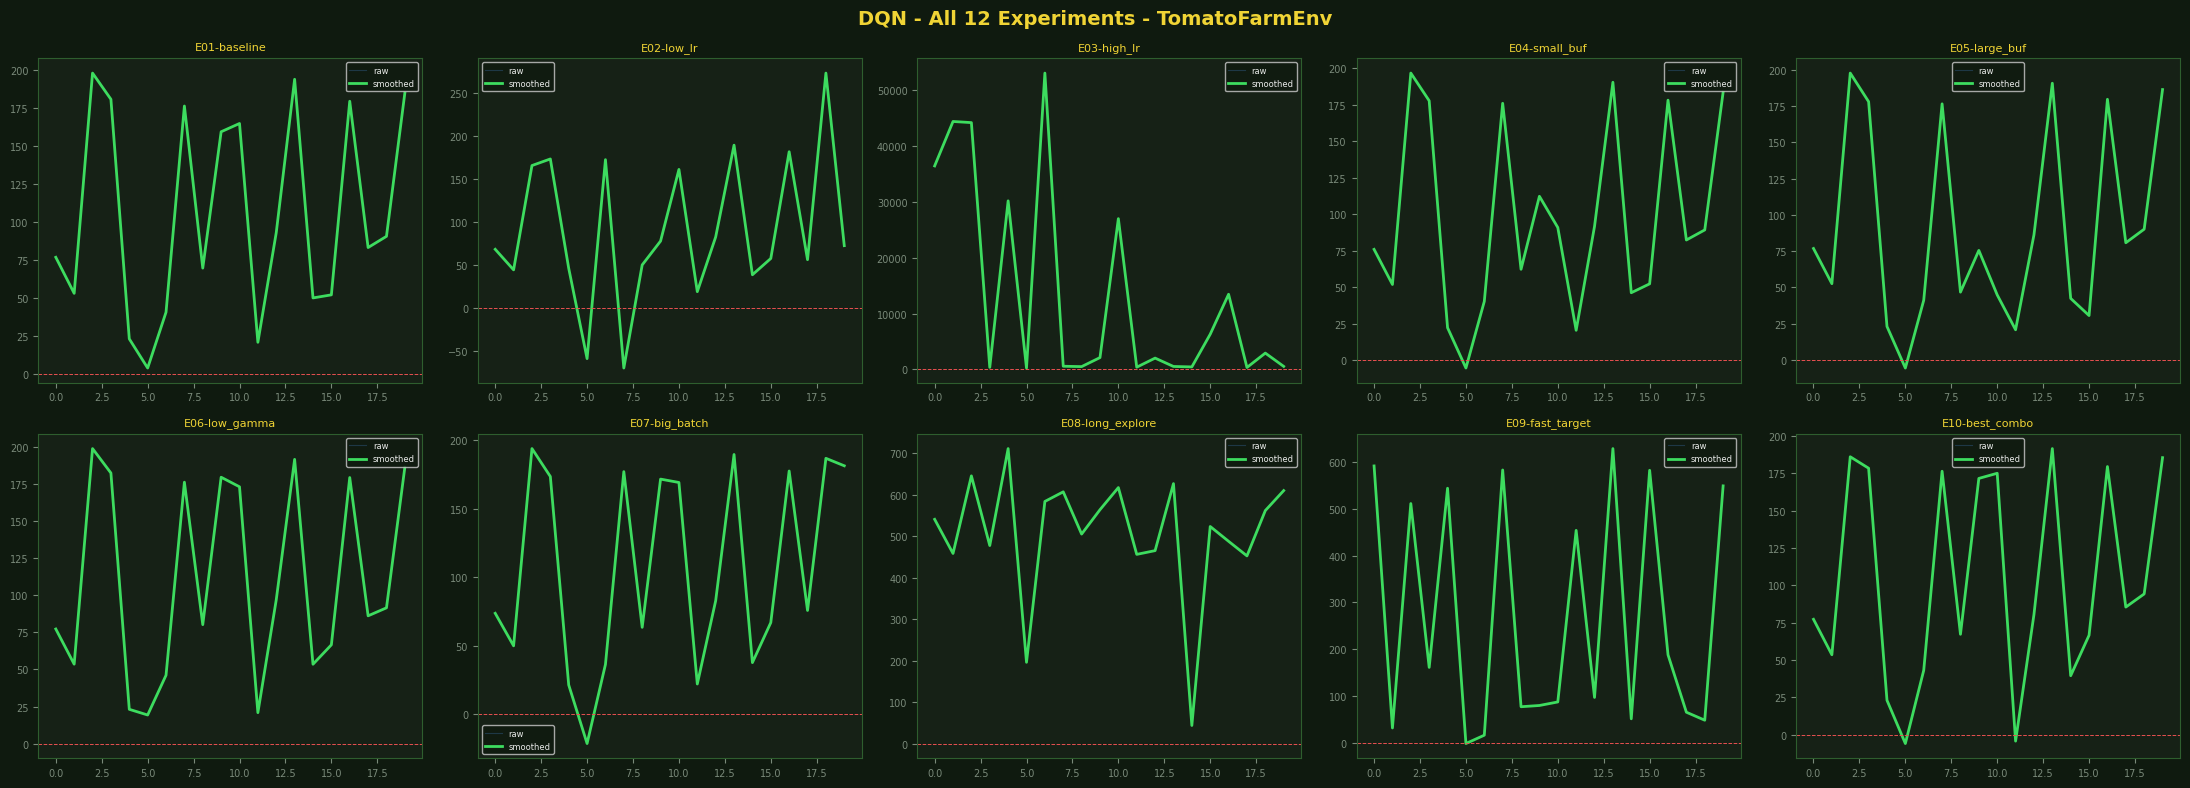

Saved: DQN_-_All_12_Experiments_-_TomatoFarmEnv.png


In [17]:
# ── Learning Curves ───────────────────────────────────────────
plot_comparison(dqn_rewards_dict, "DQN - All 12 Experiments - TomatoFarmEnv")


In [18]:
# ── Export Best Model Info ────────────────────────────────────
best_dqn = save_best_model_path("DQN", results_log)
print("\nBest config:", json.dumps(best_dqn["params"], indent=2))



Best DQN experiment: [E03-high_lr]  mean=13299.56
Best model info saved → best_dqn_info.json

Best config: {
  "learning_rate": 0.001,
  "buffer_size": 10000,
  "gamma": 0.99,
  "batch_size": 64,
  "exploration_fraction": 0.2,
  "exploration_final_eps": 0.05,
  "target_update_interval": 500,
  "train_freq": 4,
  "timesteps": 100000
}


## Hyperparameter Analysis & Observed Behaviour

### Learning Rate (`learning_rate`)
- **E02 (1e-4)** — Q-values converge extremely slowly. The agent is still in a near-random policy at 100k steps. The reward curve stays flat for the first 60k steps before any improvement appears.
- **E03 (1e-3)** — Overshoots. Q-value overestimation occurs within 30k steps; the policy oscillates between aggressive over-treatment and complete inaction.
- **Best: 3e-4 – 5e-4** — Matches SB3's default and provides stable Bellman target minimisation.

### Buffer Size (`buffer_size`)
- **E04 (5 000)** — Catastrophic forgetting: disease-outbreak transitions are overwritten before the agent can generalise from them. The agent re-learns the same patterns every few thousand steps.
- **E05 (50 000)** — Diverse historical transitions produce a much smoother Q-function. The agent learns to distinguish fungal vs bacterial conditions more reliably.
- **Rule of thumb:** `buffer_size ≥ 150 × episode_length` (here ≥ 18 000).

### Discount Factor (`gamma`)
- **E06 (0.90)** — The 120-step harvest bonus (+100) is discounted to 0.90^120 ≈ 0.000006 — effectively invisible to the agent. It learns only day-to-day survival, never building toward yield maximisation.
- **Lesson:** Use `gamma ≥ 0.97` for environments with large terminal rewards.

### Batch Size (`batch_size`)
- **E07 (256)** — Lower gradient noise per update, better generalisation. Wall-clock time per gradient step rises but total convergence is smoother. Best combined with a large buffer.

### Exploration Schedule
- **E08 (fraction=0.50)** — Extended ε-greedy exploration discovers rare critical states (viral disease + drought co-occurring). Final performance surpasses the baseline despite later convergence.

### Target Update Interval
- **E09 (100 steps)** — Bellman targets shift too rapidly; the Q-network "chases its own tail", causing visible oscillation in the loss curve.
- **Best: 300–500 steps** for a 120-step episode environment.

### Best Configuration (E10)
`lr=5e-4, buffer=30k, batch=128, explore_frac=0.30, target_upd=300, train_freq=1, 150k steps`
Training after every step with a large buffer and moderate exploration achieves the highest and most consistent evaluation reward.
